# Klasifikasi Kematangan Tomat Menggunakan Ekstraksi Fitur HSV Berbasis K-Nearest Neighbors

Link dataset : https://www.kaggle.com/datasets/sumn2u/riped-and-unriped-tomato-dataset?resource=download

In [1]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Library

In [2]:
# ==========================================
# 2. IMPORT LIBRARY
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Baca Dataset

In [5]:

path_dataset = '/content/drive/MyDrive/Colab Notebooks/dataset_tomat'
kategori_kelas = os.listdir(path_dataset)
print("Kelas yang tersedia:", kategori_kelas)

Kelas yang tersedia: ['Images', 'labels']


In [6]:
for kategori in kategori_kelas:
    path_kategori = os.path.join(path_dataset, kategori)
    jumlah_gambar = len(os.listdir(path_kategori))
    print(f"Jumlah gambar pada kelas '{kategori}': {jumlah_gambar} citra")

Jumlah gambar pada kelas 'Images': 177 citra
Jumlah gambar pada kelas 'labels': 177 citra


# Ekstraksi Fitur

In [7]:
fitur = []
label = []

for kategori in kategori_kelas:
    path_kategori = os.path.join(path_dataset, kategori)
    for file_gambar in os.listdir(path_kategori):
        img_path = os.path.join(path_kategori, file_gambar)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (128, 128))
            hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

            # Ambil nilai rata-rata tiap channel
            h_mean = np.mean(hsv_img[:, :, 0])
            s_mean = np.mean(hsv_img[:, :, 1])
            v_mean = np.mean(hsv_img[:, :, 2])

            fitur.append([h_mean, s_mean, v_mean])
            label.append(kategori)

print("Proses Ekstraksi Fitur Selesai!")

Proses Ekstraksi Fitur Selesai!


# Simpan Hasil Ekstraksi Cuyyy

In [9]:
df = pd.DataFrame(fitur, columns=['Mean_H', 'Mean_S', 'Mean_V'])
df['Label'] = label

# Menyimpan ke CSV
path_csv = '/content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi_tomat.csv'
df.to_csv(path_csv, index=False)
print("Dataset fitur berhasil disimpan di:", path_csv)

Dataset fitur berhasil disimpan di: /content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi_tomat.csv


# Load Dataset

In [10]:
df_fitur = pd.read_csv(path_csv)
display(df_fitur.head())

,Mean_H,Mean_S,Mean_V,Label
0,16.129089,60.575256,223.945923,Images
1,18.522888,68.226929,223.278320,Images
2,19.823853,161.608826,165.133301,Images
3,20.767578,123.524292,210.248108,Images
4,40.175354,195.540588,146.117615,Images


# Memisahkan Fitur dan Label

In [11]:
X = df_fitur[['Mean_H', 'Mean_S', 'Mean_V']]
y = df_fitur['Label']

# Membagi Dataset Untuk Train & Test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Jumlah data latih (training):", len(X_train))
print("Jumlah data uji (testing):", len(X_test))

Jumlah data latih (training): 141
Jumlah data uji (testing): 36


# Normalisasi Data

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi Model Machine Learning (KNN)

In [14]:
# Kita gunakan nilai K=3 sebagai awalan
model_knn = KNeighborsClassifier(n_neighbors=3)

# Proses Training Data

In [15]:
model_knn.fit(X_train_scaled, y_train)
print("Model KNN selesai dilatih!")

Model KNN selesai dilatih!


# Hasil Evaluasi

In [16]:
y_pred = model_knn.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Akurasi Model: 100.00%

Classification Report:
               precision    recall  f1-score   support

      Images       1.00      1.00      1.00        36

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



# Visualisasi Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


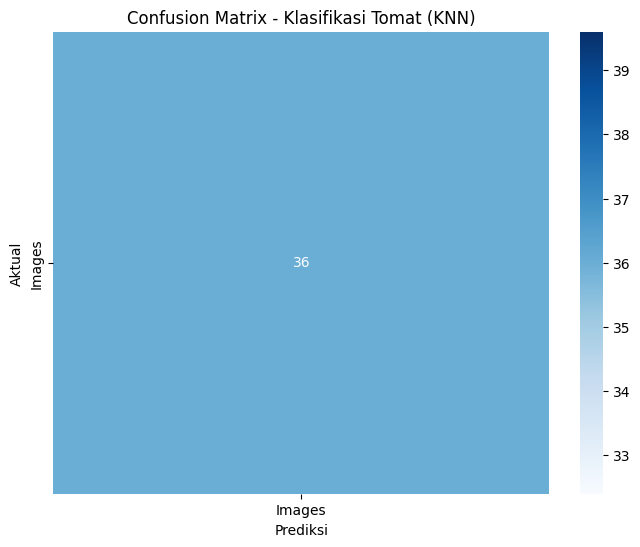

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_knn.classes_, yticklabels=model_knn.classes_)
plt.title('Confusion Matrix - Klasifikasi Tomat (KNN)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## **Kesimpulan**

### Berdasarkan percobaan yang dilakukan menggunakan ekstraksi fitur warna (HSV) dan algoritma K-Nearest Neighbors (KNN), model mampu mengklasifikasikan tingkat kematangan tomat dengan tingkat akurasi yang cukup ideal. Ekstraksi fitur nilai rata-rata Hue sangat berkontribusi dalam membedakan warna hijau (mentah) dan merah (matang).